In [10]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier 
from sklearn.tree import DecisionTreeClassifier 

random_state = 42

In [11]:
'''
- Tìm hiểu cấu trúc data tại trang web UCI
- Down các files, đặt trong folder data/
- Làm với phiên bản 'numeric'
'''
data_path = 'german.data-numeric'
credit=np.genfromtxt(data_path)
print(credit)
X,y = credit[:,:-1], credit[:,-1]
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)



[[ 1.  6.  4. ...  0.  1.  1.]
 [ 2. 48.  2. ...  0.  1.  2.]
 [ 4. 12.  4. ...  1.  0.  1.]
 ...
 [ 4. 12.  2. ...  0.  1.  1.]
 [ 1. 45.  2. ...  0.  1.  2.]
 [ 2. 45.  4. ...  0.  1.  1.]]
(1000, 24) (1000,)
(800, 24) (200, 24)


In [12]:
#Bai 1

In [13]:
'''
- Decision Tree
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
'''
DT = DecisionTreeClassifier(random_state=random_state)

'''
- Random Forest
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
'''
RF = RandomForestClassifier(random_state=random_state)

In [14]:
print('Demo DT and RF prediction')
DT.fit(X_train, y_train)
y_dt_pred = DT.predict(X_test)
print("-DT acc = {}".format(accuracy_score(y_test, y_dt_pred)))
print("-DT f1 = {}".format(f1_score(y_test, y_dt_pred)))
print("-DT roc auc = {}".format(roc_auc_score(y_test, y_dt_pred)))
print(confusion_matrix(y_test, y_dt_pred))

Demo DT and RF prediction
-DT acc = 0.665
-DT f1 = 0.7632508833922261
-DT roc auc = 0.5948431301839163
[[108  33]
 [ 34  25]]


In [15]:
#Bai1

RF.fit(X_train, y_train)
y_rf_pred = RF.predict(X_test)
print("-RF acc = {}".format(accuracy_score(y_test, y_rf_pred)))
print("-RF f1 = {}".format(f1_score(y_test, y_rf_pred)))
print("-RF roc auc = {}".format(roc_auc_score(y_test, y_rf_pred)))
print(confusion_matrix(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred))

-RF acc = 0.81
-RF f1 = 0.875
-RF roc auc = 0.7173939175381656
[[133   8]
 [ 30  29]]
              precision    recall  f1-score   support

         1.0       0.82      0.94      0.88       141
         2.0       0.78      0.49      0.60        59

    accuracy                           0.81       200
   macro avg       0.80      0.72      0.74       200
weighted avg       0.81      0.81      0.80       200



In [16]:
# Utility functions
def grid_search(algorithm, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier()
    if algorithm == 'random-forest':
        model = RandomForestClassifier()
    classifier = GridSearchCV(estimator=model, cv=5, param_grid=dict_param,
                            n_jobs=n_jobs, scoring='f1')
    classifier.fit(X_train, y_train)
    print('Best model', end='')
    print(classifier.best_estimator_)
    return classifier.best_estimator_

def evaluate(model): 
    print("Train Accuracy :", accuracy_score(y_train, model.predict(X_train)))
    print("Train f1 score :", f1_score(y_train, model.predict(X_train)))  
    print("Train roc auc :", roc_auc_score(y_train, model.predict(X_train)))  
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-"*50)
    print("Test Accuracy :", accuracy_score(y_test, model.predict(X_test)))
    print("Test f1 score :", f1_score(y_test, model.predict(X_test)))
    print("Test roc auc :", roc_auc_score(y_test, model.predict(X_test)))  
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))

def plot_learning_curve(estimator, title, label_curve, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5), new_plot=False,
                        idx_color=0):
    # Khởi tạo bức ảnh mới với thư viện plot lib 
    if new_plot:
        # plt.figure()
        plt.title(title)
        plt.xlabel("Training examples")
        plt.ylabel("Score")
        plt.grid()
    # chú thích nếu có 
    if ylim is not None:
        plt.ylim(*ylim)
        
    # thực hiện training model, ghi nhận các giá trị trong quá trình training 
    # cv = số fold cross validate, số phần bộ dữ liệu được chia để thực hiện training testing.
    # train_sizes = mảng tỉ lệ, các tỉ lệ được hệ thống chọn làm điểm dừng để thực hiện 1 testing 
    #  train_sizes = [0.3, 0.5] => hệ thống lấy 30 % dữ liệu để train và thực hiện test, tương tự 50 % ..
    # scoring = hàm mục tiêu để đánh giá chất lượng mô hình và vẽ lên đồ thị 
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="f1")
    # Lấy trung bình cộng các giá trị output của các fold 
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # thực hiện vẽ các giá trị số lên đồ thị với màu vừa được random 
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='g')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='r',
             label=label_curve['test'])
    plt.plot(train_sizes, train_scores_mean, 'o-', color='g',
             label=label_curve['train'])

    plt.legend(loc="best")
    return plt

Text(0.5, 1.0, 'DT validation curve for max_depth')

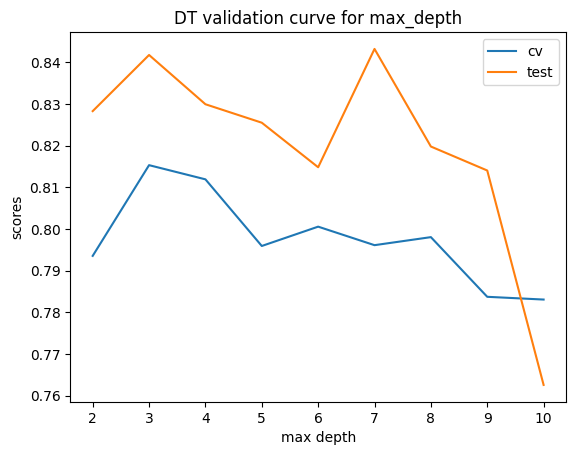

In [17]:
# Trước hết, hãy thử khảo sát DT với tham số max_depth
cv_accuracies_by_depth, test_accuracies_by_depth= [], []
max_depth_values= np.arange(2,11)

for curr_max_depth in max_depth_values:
  tree= DecisionTreeClassifier(random_state=random_state, max_depth=curr_max_depth)
  
  # cross-validation
  val_scores= cross_val_score(estimator=tree, X=X_train, y=y_train, cv=5, scoring='f1')
  cv_accuracies_by_depth.append(val_scores.mean())

  # test
  tree.fit(X_train, y_train)
  curr_pred= tree.predict(X_test)
  test_accuracies_by_depth.append(f1_score(curr_pred, y_test))

# Plot 
plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')

In [18]:
# Thử sử dụng GridSearchCV để khảo sát
dict_param = {
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_tree = grid_search('decision-tree', n_jobs=-1, dict_param=dict_param)


Best modelDecisionTreeClassifier(max_depth=5, min_samples_leaf=20)


Train Accuracy : 0.77125
Train f1 score : 0.8473728106755629
Train roc auc : 0.680523905314024
Train Confusion Matrix:
[[508  51]
 [132 109]]
--------------------------------------------------
Test Accuracy : 0.78
Test f1 score : 0.8533333333333334
Test roc auc : 0.6911888448130785
Test Confusion Matrix:
[[128  13]
 [ 31  28]]


<module 'matplotlib.pyplot' from 'c:\\Users\\hungn\\miniconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

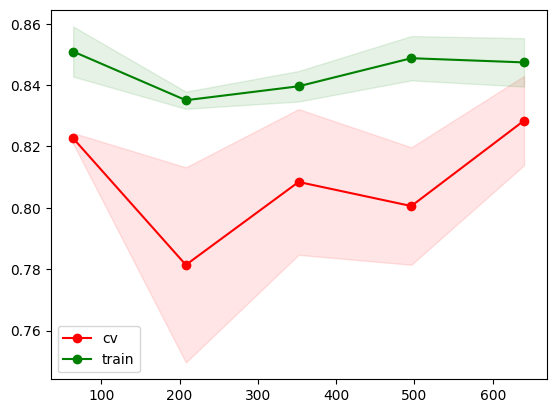

In [21]:
best_tree.fit(X_train, y_train)
evaluate(best_tree)
title = 'Learning curve with best tree'
label_curve = {'train': 'train', 'test':'cv'}
plot_learning_curve(best_tree, title, label_curve
                    , X_train, y_train, cv=5)


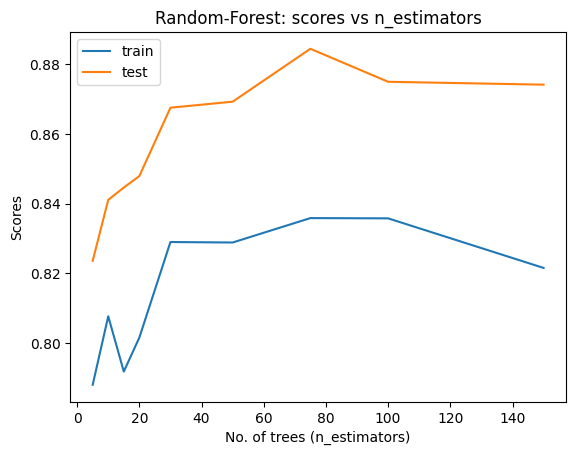

In [ ]:
#Bai 3
num_trees = [5, 10, 15, 20, 30, 50, 75, 100, 150]
train_acc = []
test_acc = []
for ntrees in num_trees:
    rf = RandomForestClassifier(n_estimators=ntrees, random_state=random_state, n_jobs=-1).fit(X_train, y_train)
    temp_train_acc = cross_val_score(rf, X_test, y_test, cv= 5, scoring='f1')
    train_acc.append(temp_train_acc.mean())
    test_acc.append(f1_score(rf.predict(X_test), y_test))
plt.plot(num_trees, train_acc, label='train')
plt.plot(num_trees, test_acc, label='test')
plt.legend()
plt.xlabel('No. of trees (n_estimators)')
plt.ylabel('Scores')
plt.title('Random-Forest: scores vs n_estimators');

In [24]:
dict_param = {
    'max_depth': [3, 11, 15, 24, 27], 
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features':  [4, 6, 10, 16],
    'n_estimators': [75]
}


In [25]:
best_forest = grid_search('random-forest', n_jobs=-1, dict_param=dict_param)

Best modelRandomForestClassifier(max_depth=24, max_features=6, min_samples_leaf=5,
                       n_estimators=75)


Train Accuracy : 0.88125
Train f1 score : 0.9206349206349206
Train roc auc : 0.8123464396261849
Train Confusion Matrix:
[[551   8]
 [ 87 154]]
--------------------------------------------------
Test Accuracy : 0.77
Test f1 score : 0.8516129032258064
Test roc auc : 0.6545257843490804
Test Confusion Matrix:
[[132   9]
 [ 37  22]]


<module 'matplotlib.pyplot' from 'c:\\Users\\hungn\\miniconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

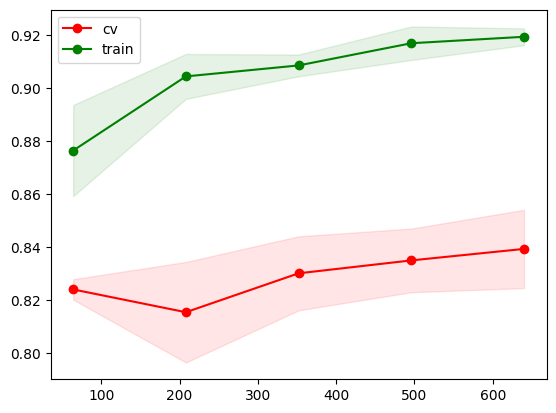

In [26]:
evaluate(best_forest)
title = 'Learning Curve'
label_curve = {'train':'train', 'test':'cv'}
plot_learning_curve(best_forest, title, label_curve, X_train, y_train, cv = 5)

10 su that no nao ve feature importance?????
Feature 0 0.17660412657061364
Feature 1 0.13382336198683747
Feature 2 0.11161867696628258
Feature 3 0.10618462807613689
Feature 4 0.09232970936800536
Feature 5 0.049350324871911835
Feature 6 0.04845693660078552
Feature 7 0.04807765428735065
Feature 8 0.03374796884134647
Feature 9 0.030332049082579114


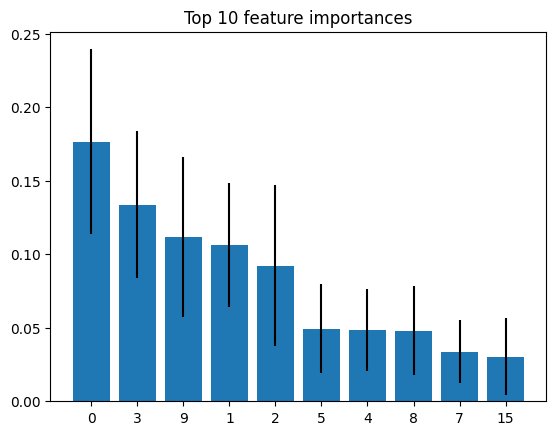

In [28]:
best_forest.fit(X_train, y_train)
importances = best_forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in best_forest.estimators_], axis=0)
indices = np.argsort(importances)[::-1]
print('10 su that no nao ve feature importance?????')
for i in range(10):
    print('Feature',i, importances[indices[i]])
indices = indices[:10]
plt.figure()
plt.title('Top 10 feature importances')
plt.bar(range(10), importances[indices], yerr=std[indices])
plt.xticks(range(10), indices)
plt.show()

In [29]:
# Thử bỏ một sô feature có độ quan trọng thấp đi
# Chú ý tham max_features cần thay đổi
sfm = SelectFromModel(best_forest, threshold='mean')
sfm.fit(X_train, y_train)
X_train_dropped = sfm.transform(X_train)
X_test_dropped = sfm.transform(X_test)

title = 'Learning with dropped features'
label_curve = {'train': 'train', 'test':'cv'}
forest_dropped = RandomForestClassifier(max_depth=11, min_samples_leaf=5,
                       n_estimators=75, n_jobs=-1, random_state=random_state)

# plot_learning_curve(forest_dropped, title, label_curve, X_train_dropped, y_train, cv=5)

forest_dropped.fit(X_train_dropped, y_train)
y_dropped_pred = forest_dropped.predict(X_test_dropped)
print('acc', accuracy_score(y_test, y_dropped_pred))
print('f1', f1_score(y_test, y_dropped_pred))
print('roc_auc', roc_auc_score(y_test, y_dropped_pred))

acc 0.79
f1 0.8618421052631579
roc_auc 0.6933525664142326


In [30]:
'''
- Standard RF
'''
params = {
    'max_depth': best_forest.get_params()['max_depth'],
    'max_features': best_forest.get_params()['max_features'],
    'min_samples_leaf': best_forest.get_params()['min_samples_leaf'],
    'n_estimators': best_forest.get_params()['n_estimators'],
}
evaluate(best_forest)


Train Accuracy : 0.88125
Train f1 score : 0.9202350965575147
Train roc auc : 0.8158871428677469
Train Confusion Matrix:
[[548  11]
 [ 84 157]]
--------------------------------------------------
Test Accuracy : 0.79
Test f1 score : 0.8636363636363636
Test roc auc : 0.6834956124534199
Test Confusion Matrix:
[[133   8]
 [ 34  25]]
